In [1]:
from Functional_Fusion.dataset import DataSetMDTB
from Functional_Fusion.dataset import DataSetLanguage
import numpy as np
import pandas as pd
from Functional_Fusion import atlas_map as am
import nitools as nt
import SUITPy.flatmap as flatmap
import matplotlib.pyplot as plt
from itertools import combinations
from itertools import combinations_with_replacement



No protocol specified


In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
# Define a list of colorspatial_navigation
colors = ["#62c4ff", "#3a93f7", "#1e6bf9",'#1244d7','#e55b2d','#e86c22','#f8d24d','#f3f36d']

custom_cmap = LinearSegmentedColormap.from_list("custom_colormap", colors)

In [3]:
base_dir = '/cifs/diedrichsen/data/FunctionalFusion'

# Define ROI

In [4]:
# ROI_labels = ['S1L', 'S2L', 'S3L', 'S4L', 'S5L', 'S1R', 'S2R', 'S3R', 'S4R', 'S5R']
ROI_labels = ['S1R', 'S2R']
# ROI_labels = ['D1L', 'D2L', 'D3L', 'D4L', 'D1R', 'D2R', 'D3R', 'D4R']
ROI_labels = ['M1L', 'M2L', 'M3L', 'M4L', 'M1R', 'M2R', 'M3R', 'M4R']

<Axes: >

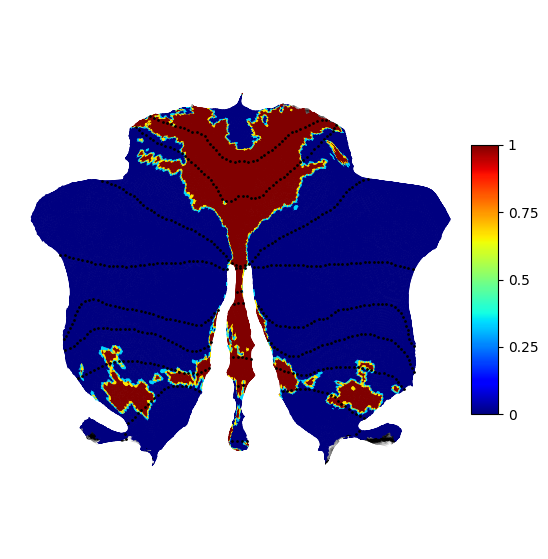

In [6]:
atlas, _ = am.get_atlas('SUIT3')
atlas_dir = f'{base_dir}/Atlases/tpl-SUIT'
model_name = f'/atl-NettekovenSym32_space-SUIT_dseg.nii'
U = atlas.read_data(atlas_dir + model_name)
U = U.T
_, cmap, labels = nt.read_lut(f'{atlas_dir}/atl-NettekovenSym32.lut')
ROI_mask = np.zeros_like(U)
for i, label in enumerate(labels):
    if label in ROI_labels:
        ROI_mask[U == i] = 1

lang_img = atlas.data_to_nifti(ROI_mask)
surface = flatmap.vol_to_surf(lang_img, space='SUIT',stats = 'mode')
flatmap.plot(data=surface, new_figure=True, colorbar=True, render='matplotlib')

# Compare localizer data unstable baseline vs mean of all conditions

In [6]:
Language_dataset = DataSetLanguage(f'{base_dir}/Language')
data_language_unstable,info_language  =Language_dataset.get_data(space='SUIT3',ses_id='ses-localizer_cond',type='CondRun')
data_language_unstable = np.nanmean(data_language_unstable,axis =0)
mean_across_conds = np.nanmean(data_language_unstable,axis =0)
data_language_mean_subtracted = data_language_unstable - mean_across_conds

/tmp/ipykernel_417546/2502605690.py:3: RuntimeWarning: Mean of empty slice
  data_language_unstable = np.nanmean(data_language_unstable,axis =0)
/tmp/ipykernel_417546/2502605690.py:4: RuntimeWarning: Mean of empty slice
  mean_across_conds = np.nanmean(data_language_unstable,axis =0)


In [7]:
data_language_unstable_clean = np.nan_to_num(data_language_unstable, nan=0.0)
data_language_mean_subtracted_clean = np.nan_to_num(data_language_mean_subtracted, nan=0.0)

# Now compute the covariance matrix across conditions
cov_matrix_unstable = np.cov(data_language_unstable_clean.T, rowvar=False)
cov_matrix_conditions_mean_subtracted = np.cov(data_language_mean_subtracted_clean.T, rowvar=False)


Text(0.5, 1.0, 'Covariance Matrix Across Conditions\n(Data Language Mean Subtracted)')

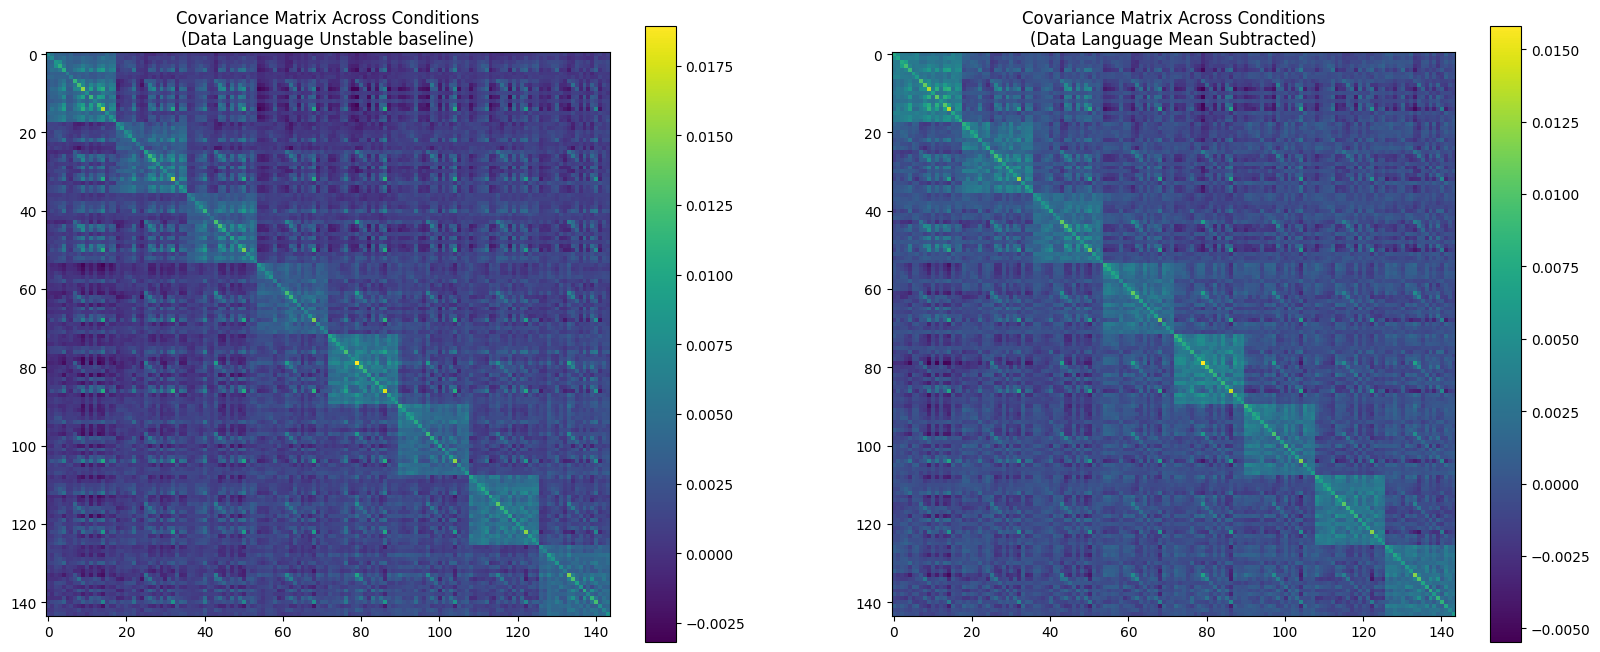

In [8]:
plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
plt.imshow(cov_matrix_unstable)
plt.colorbar()
plt.title('Covariance Matrix Across Conditions\n(Data Language Unstable baseline)')

plt.subplot(1, 2, 2)
plt.imshow(cov_matrix_conditions_mean_subtracted,)
plt.colorbar()
plt.title('Covariance Matrix Across Conditions\n(Data Language Mean Subtracted)')


In [9]:
n_conditions = 144
n_tasks = 18  
n_runs = 8

task_labels = np.tile(np.arange(n_tasks), n_runs)
run_labels = np.repeat(np.arange(n_runs), n_tasks)

# Unstable baseline

In [10]:
sum_cov_diff_tasks_diff_runs = 0.0
count = 0


for i in range(n_conditions):
    for j in range(i , n_conditions):
        if task_labels[i] != task_labels[j] and run_labels[i] != run_labels[j]:
            sum_cov_diff_tasks_diff_runs += cov_matrix_conditions_mean_subtracted[i, j]
            count += 1

variance_4 = sum_cov_diff_tasks_diff_runs /count
print(variance_4)


-0.0005274905478245859


In [11]:
sum_cov_same_tasks_diff_runs = 0.0
count = 0

for i in range(len(task_labels)):
    for j in range(i , len(task_labels)):
        if task_labels[i] == task_labels[j] and run_labels[i] != run_labels[j]:
            sum_cov_same_tasks_diff_runs += cov_matrix_unstable[i, j]
            count += 1

variance_3 = sum_cov_same_tasks_diff_runs / count
print(variance_3)


0.0030989225724609316


In [12]:
sum_cov_diff_tasks_same_run = 0.0
count_diff_tasks_same_run = 0

for i in range(len(task_labels)):
    for j in range(i , len(task_labels)):
        if task_labels[i] != task_labels[j] and run_labels[i] == run_labels[j]:
            sum_cov_diff_tasks_same_run += cov_matrix_conditions_mean_subtracted[i, j]
            count_diff_tasks_same_run += 1

variance_2 = sum_cov_diff_tasks_same_run / count
print(variance_2)


0.0064790958357702245


In [13]:
sum_cov_same_tasks_same_run = 0.0
count_same_tasks_same_run = 0

for i in range(len(task_labels)):
    for j in range(i , len(task_labels)):
        if task_labels[i] == task_labels[j] and run_labels[i] == run_labels[j]:
            sum_cov_same_tasks_same_run += cov_matrix_unstable[i, j]
            count_same_tasks_same_run += 1

variance_1 = sum_cov_same_tasks_same_run / count
print(variance_1)


0.002656055002247019


In [14]:
variance_1 - variance_3

-0.00044286757021391255

# Mean of all conditions

In [15]:
sum_cov_same_tasks_diff_runs = 0.0
count = 0

for i in range(len(task_labels)):
    for j in range(i , len(task_labels)):
        if task_labels[i] == task_labels[j] and run_labels[i] != run_labels[j]:
            sum_cov_same_tasks_diff_runs += cov_matrix_conditions_mean_subtracted[i, j]
            count += 1

variance_3 = sum_cov_same_tasks_diff_runs / count
print(variance_3)


0.0014025543006663363


In [16]:
sum_cov_same_tasks_same_run = 0.0
count_same_tasks_same_run = 0

for i in range(len(task_labels)):
    for j in range(i , len(task_labels)):
        if task_labels[i] == task_labels[j] and run_labels[i] == run_labels[j]:
            sum_cov_same_tasks_same_run += cov_matrix_conditions_mean_subtracted[i, j]
            count_same_tasks_same_run += 1

variance_1 = sum_cov_same_tasks_same_run / count
print(variance_1)


0.0021713783531628473


In [17]:
variance_1 - variance_3

0.000768824052496511

# Load data

In [18]:
MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb,info_mdtb  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s1',type='CondAll')
data_mdtb =np.nanmean(data_mdtb,axis =0)


/tmp/ipykernel_417546/1841978593.py:3: RuntimeWarning: Mean of empty slice
  data_mdtb =np.nanmean(data_mdtb,axis =0)


In [19]:
info_mdtb.cond_name

0                  NoGo
1                    Go
2                   ToM
3              VideoAct
4            VideoKnots
5      UnpleasantScenes
6        PleasantScenes
7                  Math
8        DigitJudgement
9          CheckerBoard
10             SadFaces
11           HappyFaces
12       IntervalTiming
13         MotorImagery
14         FingerSimple
15            FingerSeq
16          Verbal0Back
17          Verbal2Back
18          Object0Back
19          Object2Back
20    SpatialNavigation
21          StroopIncon
22            StroopCon
23              VerbGen
24             WordRead
25    VisualSearchSmall
26      VisualSearchMed
27    VisualSearchLarge
28                 rest
Name: cond_name, dtype: object

In [20]:
Language_dataset = DataSetLanguage(f'{base_dir}/Language')
data_language,info_language  =Language_dataset.get_data(space='SUIT3',ses_id='ses-localizer_cond',type='CondAll')
info_language['taskName'] = info_language['taskName'].str.strip()
data_language =np.nanmean(data_language,axis =0)
mean_across_conds = np.nanmean(data_language,axis =0)
data_language = data_language - mean_across_conds


/tmp/ipykernel_417546/1797386431.py:4: RuntimeWarning: Mean of empty slice
  data_language =np.nanmean(data_language,axis =0)
/tmp/ipykernel_417546/1797386431.py:5: RuntimeWarning: Mean of empty slice
  mean_across_conds = np.nanmean(data_language,axis =0)


In [21]:
data_language.shape

(18, 6918)

In [22]:
info_language.taskName

0                          rest
1                  word_reading
2               verb_GENERATION
3     action_observation_action
4            action_observation
5                intact_passage
6              degraded_passage
7               tongue_movement
8               finger_sequence
9                theory_of_mind
10           auditory_narrative
11                       n_back
12                      oddball
13                  demand_grid
14                romance_movie
15           spatial_navigation
16             sentence_reading
17              nonword_reading
Name: taskName, dtype: object

In [23]:
shared_conditions =[('theory_of_mind','ToM'),('rest','rest'),('finger_sequence','FingerSeq'),('action_observation_action','VideoAct'),('action_observation','VideoKnots'),('verb_GENERATION','VerbGen'),('word_reading','WordRead'),('spatial_navigation','SpatialNavigation')]

In [24]:
shared_conditions

[('theory_of_mind', 'ToM'),
 ('rest', 'rest'),
 ('finger_sequence', 'FingerSeq'),
 ('action_observation_action', 'VideoAct'),
 ('action_observation', 'VideoKnots'),
 ('verb_GENERATION', 'VerbGen'),
 ('word_reading', 'WordRead'),
 ('spatial_navigation', 'SpatialNavigation')]

In [25]:
# for cond_lang, cond_mdtb in shared_conditions:
#     # Get index for MDTB and Language data
#     idx_mdtb = info_mdtb[info_mdtb.cond_name == cond_mdtb].index
#     idx_lang = info_language[info_language.taskName == cond_lang].index

#     if not idx_mdtb.empty and not idx_lang.empty:
#         # Plot MDTB data
#         mdtb_img = atlas.data_to_nifti(data_mdtb[idx_mdtb[0]])
#         surface_mdtb = flatmap.vol_to_surf(mdtb_img, space='SUIT', stats='nanmean')
#         plt.figure()
#         flatmap.plot(data=surface_mdtb, colorbar=True, render='matplotlib', cmap=custom_cmap)
#         plt.title(f'MDTB - {cond_mdtb}')
#         plt.show()

#         # Plot Language data
#         language_img = atlas.data_to_nifti(data_language[idx_lang[0]])
#         surface_lang = flatmap.vol_to_surf(language_img, space='SUIT', stats='nanmean')
#         plt.figure()
#         flatmap.plot(data=surface_lang, colorbar=True, render='matplotlib',cmap=custom_cmap)
#         plt.title(f'Language - {cond_lang}')
#         plt.show()

# Align each dataset to REST then average shared, stack all conds and align to mean of all tasks

In [26]:
# Subtract rest
rest_index = info_mdtb[info_mdtb['cond_name'] == 'rest'].index
data_mdtb_vrest = data_mdtb - data_mdtb[rest_index,:]

rest_index = info_language[info_language['taskName'] == 'rest'].index
data_language_vrest = data_language - data_language[rest_index,:]


In [27]:
# Average shared conds and add novel conds
shared_data = []
shared_labels = []

for lang_cond, mdtb_cond in shared_conditions:
    mdtb_index = info_mdtb[info_mdtb['cond_name'] == mdtb_cond].index
    lang_index = info_language[info_language['taskName'] == lang_cond].index
    
    if not mdtb_index.empty and not lang_index.empty:
        mdtb_cond_data = data_mdtb_vrest[mdtb_index, :].squeeze()
        lang_cond_data = data_language_vrest[lang_index, :].squeeze()
        
        # Average data across the shared conditions
        avg_data = (mdtb_cond_data + lang_cond_data) / 2
        shared_data.append(avg_data)
        shared_labels.append(mdtb_cond)  # use MDTB cond names for shared conditions

# Convert tp np array
shared_data = np.array(shared_data)

# Extract novel tasks from each dataset, excluding shared tasks
novel_data_mdtb = data_mdtb_vrest[~info_mdtb['cond_name'].isin([cond[1] for cond in shared_conditions]), :]
novel_data_language = data_language_vrest[~info_language['taskName'].isin([cond[0] for cond in shared_conditions]), :]

# Combine shared data with novel 
combined_data_v1 = np.vstack([shared_data, novel_data_mdtb, novel_data_language])

# Combine labels for shared and novel
combined_labels = shared_labels + \
                  info_mdtb[~info_mdtb['cond_name'].isin([cond[1] for cond in shared_conditions])]['cond_name'].tolist() + \
                  info_language[~info_language['taskName'].isin([cond[0] for cond in shared_conditions])]['taskName'].tolist()

# Create new info df
new_info_v1 = pd.DataFrame({
    'taskName': combined_labels,
    'source': ['shared']*len(shared_labels) + ['mdtb']*novel_data_mdtb.shape[0] + ['language']*novel_data_language.shape[0]
})

combined_data_v1.shape,new_info_v1


((39, 6918),
               taskName    source
 0                  ToM    shared
 1                 rest    shared
 2            FingerSeq    shared
 3             VideoAct    shared
 4           VideoKnots    shared
 5              VerbGen    shared
 6             WordRead    shared
 7    SpatialNavigation    shared
 8                 NoGo      mdtb
 9                   Go      mdtb
 10    UnpleasantScenes      mdtb
 11      PleasantScenes      mdtb
 12                Math      mdtb
 13      DigitJudgement      mdtb
 14        CheckerBoard      mdtb
 15            SadFaces      mdtb
 16          HappyFaces      mdtb
 17      IntervalTiming      mdtb
 18        MotorImagery      mdtb
 19        FingerSimple      mdtb
 20         Verbal0Back      mdtb
 21         Verbal2Back      mdtb
 22         Object0Back      mdtb
 23         Object2Back      mdtb
 24         StroopIncon      mdtb
 25           StroopCon      mdtb
 26   VisualSearchSmall      mdtb
 27     VisualSearchMed      mdtb
 

# Align each dataset to mean of shared then average shared, stack all conds and align to mean of all tasks

In [28]:
# Subtract mean of shared conditions (more stable?)
shared_indices = []
for cond_pair in shared_conditions:
    mdtb_index = info_mdtb[info_mdtb['cond_name'] == cond_pair[1]].index
    shared_indices.append(mdtb_index)
data_mdtb_vshared = data_mdtb - np.nanmean(data_mdtb[shared_indices,:].squeeze(),axis=0)
print(data_mdtb_vshared.shape)


shared_indices = []
for cond_pair in shared_conditions:
    language_index = info_language[info_language['taskName'] == cond_pair[0]].index
    shared_indices.append(language_index)
data_language_vshared = data_language - np.nanmean(data_language[shared_indices,:].squeeze(),axis=0)
print(data_language_vshared.shape)

(29, 6918)
(18, 6918)


/tmp/ipykernel_417546/4211961593.py:6: RuntimeWarning: Mean of empty slice
  data_mdtb_vshared = data_mdtb - np.nanmean(data_mdtb[shared_indices,:].squeeze(),axis=0)
/tmp/ipykernel_417546/4211961593.py:14: RuntimeWarning: Mean of empty slice
  data_language_vshared = data_language - np.nanmean(data_language[shared_indices,:].squeeze(),axis=0)


In [29]:
# Average shared conds and add novel conds
shared_data = []
shared_labels = []

for lang_cond, mdtb_cond in shared_conditions:
    mdtb_index = info_mdtb[info_mdtb['cond_name'] == mdtb_cond].index
    lang_index = info_language[info_language['taskName'] == lang_cond].index
    
    if not mdtb_index.empty and not lang_index.empty:
        mdtb_cond_data = data_mdtb_vshared[mdtb_index, :].squeeze()
        lang_cond_data = data_language_vshared[lang_index, :].squeeze()
        
        # average shared
        avg_data = (mdtb_cond_data + lang_cond_data) / 2
        shared_data.append(avg_data)
        shared_labels.append(mdtb_cond)  # use mdtb cond names for shared conds

# Convert to np
shared_data = np.array(shared_data)

# Extract novel tasks from each dataset, excluding shared tasks
novel_data_mdtb = data_mdtb_vshared[~info_mdtb['cond_name'].isin([cond[1] for cond in shared_conditions]), :]
novel_data_language = data_language_vshared[~info_language['taskName'].isin([cond[0] for cond in shared_conditions]), :]

# Combine shared data with novel data
combined_data_v2 = np.vstack([shared_data, novel_data_mdtb, novel_data_language])

# Combine labels for shared and novel data
combined_labels = shared_labels + \
                  info_mdtb[~info_mdtb['cond_name'].isin([cond[1] for cond in shared_conditions])]['cond_name'].tolist() + \
                  info_language[~info_language['taskName'].isin([cond[0] for cond in shared_conditions])]['taskName'].tolist()

# Create new info df
new_info_v2 = pd.DataFrame({
    'taskName': combined_labels,
    'source': ['shared']*len(shared_labels) + ['mdtb']*novel_data_mdtb.shape[0] + ['language']*novel_data_language.shape[0]
})

combined_data_v2.shape,new_info_v2


((39, 6918),
               taskName    source
 0                  ToM    shared
 1                 rest    shared
 2            FingerSeq    shared
 3             VideoAct    shared
 4           VideoKnots    shared
 5              VerbGen    shared
 6             WordRead    shared
 7    SpatialNavigation    shared
 8                 NoGo      mdtb
 9                   Go      mdtb
 10    UnpleasantScenes      mdtb
 11      PleasantScenes      mdtb
 12                Math      mdtb
 13      DigitJudgement      mdtb
 14        CheckerBoard      mdtb
 15            SadFaces      mdtb
 16          HappyFaces      mdtb
 17      IntervalTiming      mdtb
 18        MotorImagery      mdtb
 19        FingerSimple      mdtb
 20         Verbal0Back      mdtb
 21         Verbal2Back      mdtb
 22         Object0Back      mdtb
 23         Object2Back      mdtb
 24         StroopIncon      mdtb
 25           StroopCon      mdtb
 26   VisualSearchSmall      mdtb
 27     VisualSearchMed      mdtb
 

# MANUALLY find conditions of interest +rest, subtract the mean across conds from each voxel and check variance



In [30]:
combined_data_masked = combined_data_v1[:,ROI_mask == 1]

In [31]:
task1_index = new_info_v1[new_info_v1['taskName'] == 'FingerSeq'].index
task1_data = combined_data_masked[task1_index,:].squeeze()

task2_index = new_info_v1[new_info_v1['taskName'] == 'rest'].index
task2_data = combined_data_masked[task2_index,:].squeeze()

task3_index = new_info_v1[new_info_v1['taskName'] == 'rest'].index
task3_data = combined_data_masked[task2_index,:].squeeze()

task_rest_index = new_info_v1[new_info_v1['taskName'] == 'FingerSeq'].index
task_rest_data = combined_data_masked[task_rest_index,:].squeeze()
task_rest_data.shape

(1629,)

In [32]:
task_matrix = np.vstack((task1_data,task2_data,task3_data,task_rest_data))
task_matrix = np.nan_to_num(task_matrix)

In [33]:
mean_across_conditions = task_matrix.mean(axis=0)
mean_across_voxels = task_matrix.mean(axis=1)

normalized_task_matrix = task_matrix - mean_across_conditions


In [34]:
nn =normalized_task_matrix @ normalized_task_matrix.T
eigenvalues_nn = np.linalg.eigvals(nn)
print(eigenvalues_nn)
print(np.sum(eigenvalues_nn))

[2.20443182e+01 1.97215226e-31 1.77635684e-15 0.00000000e+00]
22.044318182570844


In [35]:
nn

array([[ 5.51107955, -5.51107955, -5.51107955,  5.51107955],
       [-5.51107955,  5.51107955,  5.51107955, -5.51107955],
       [-5.51107955,  5.51107955,  5.51107955, -5.51107955],
       [ 5.51107955, -5.51107955, -5.51107955,  5.51107955]])

# Algorithm to search all combos

In [39]:
def find_top_combinations(task_matrix, task_names, num_tasks=10, function='inverse_trace', top_n=3):
    """Finds the top N combinations of `num_tasks` that give the highest function result."""
    results = []

    # Generate all task combos
    task_indices = list(range(len(task_names)))
    i = 0
    for comb in combinations_with_replacement(task_indices, num_tasks):

        # if len(set(comb)) == 1:
        #     continue 

        if i % 100000 == 0:
            print(i)
        subset_matrix = task_matrix[np.array(comb), :]
        subset_matrix = np.nan_to_num(subset_matrix)
        subset_matrix_mean = subset_matrix.mean(axis=0)
        subset_matrix = subset_matrix - subset_matrix_mean

        varcov = subset_matrix @ subset_matrix.T

        varcov += 0.01 * np.eye(varcov.shape[0])
        
        if function == 'inverse_trace':
            inverse_cov = np.linalg.inv(varcov)
            eigenvalues = np.linalg.eigvals(inverse_cov)
            function_result = np.sum(eigenvalues)
        if function == 'trace':
            eigenvalues = np.linalg.eigvals(varcov)
            sum_eigenvalues = np.sum(eigenvalues)
            function_result = sum_eigenvalues


        
        results.append((function_result,eigenvalues, comb))
        i += 1
    
    #sort
    if function == 'inverse_trace':
        results.sort(reverse=False, key=lambda x: x[0])
    if function == 'trace':
        results.sort(reverse=True, key=lambda x: x[0])
    top_combinations = results[:top_n]
    
    return top_combinations



In [40]:
task_matrix_shared = combined_data_v2[:,ROI_mask == 1]
task_names  =new_info_v1.taskName


In [56]:
# top 3 combos for vshared
top_combinations2 = find_top_combinations(task_matrix_shared, task_names, num_tasks=4, function='inverse_trace', top_n=5)
for i, (value, eigenvalues, comb) in enumerate(top_combinations2, start=1):
    combo_task_names = [task_names[index] for index in comb]
    print(f'Combination {i}:', combo_task_names)




0
100000
Combination 1: ['FingerSeq', 'NoGo', 'tongue_movement', 'romance_movie']
Combination 2: ['FingerSeq', 'SadFaces', 'tongue_movement', 'romance_movie']
Combination 3: ['FingerSeq', 'HappyFaces', 'tongue_movement', 'romance_movie']
Combination 4: ['ToM', 'FingerSeq', 'tongue_movement', 'romance_movie']
Combination 5: ['FingerSeq', 'VisualSearchMed', 'tongue_movement', 'romance_movie']


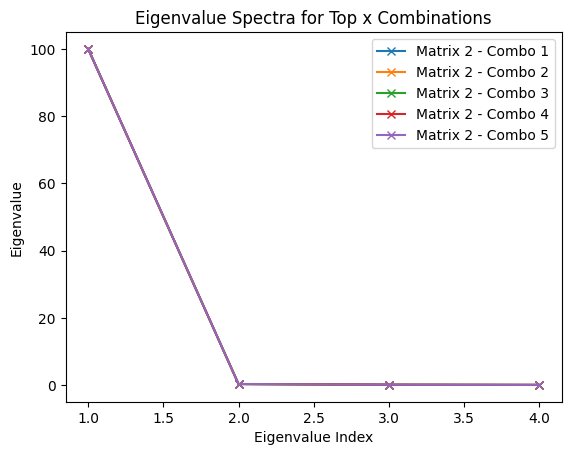

In [57]:
for i, (value, eigenvalues, comb) in enumerate(top_combinations2, start=1):
    indices = np.arange(1, len(eigenvalues) + 1)
    plt.plot(indices, sorted(eigenvalues, reverse=True), label=f'Matrix 2 - Combo {i}', marker='x')

plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalue Spectra for Top x Combinations')
plt.legend()

plt.show()

# Multitask finder  - language

<Axes: >

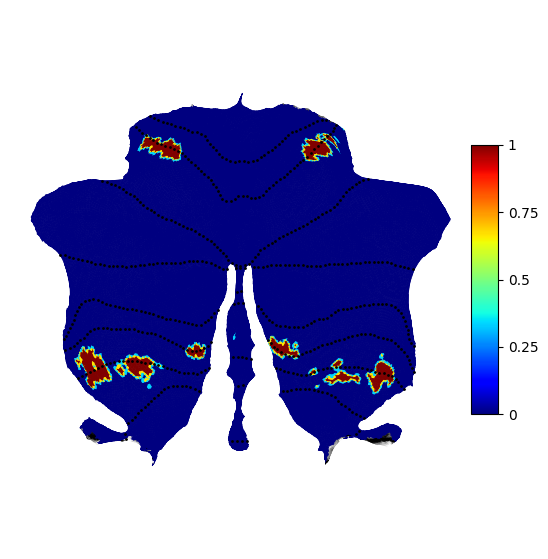

In [73]:
ROI_labels = ['S1R', 'S2R']
ROI_labels = ['A1R', 'A2R','A3R','A1L', 'A2L','A3L']

atlas, _ = am.get_atlas('SUIT3')
atlas_dir = f'{base_dir}/Atlases/tpl-SUIT'
model_name = f'/atl-NettekovenSym32_space-SUIT_dseg.nii'
U = atlas.read_data(atlas_dir + model_name)
U = U.T
_, cmap, labels = nt.read_lut(f'{atlas_dir}/atl-NettekovenSym32.lut')
ROI_mask = np.zeros_like(U)
for i, label in enumerate(labels):
    if label in ROI_labels:
        ROI_mask[U == i] = 1

lang_img = atlas.data_to_nifti(ROI_mask)
surface = flatmap.vol_to_surf(lang_img, space='SUIT',stats = 'mode')
flatmap.plot(data=surface, new_figure=True, colorbar=True, render='matplotlib')


In [74]:
task_matrix_shared = combined_data_v2[:,ROI_mask == 1]

task_names  =new_info_v1.taskName

In [75]:

# top 3 combos for vshared
top_combinations2 = find_top_combinations(task_matrix_shared, task_names, num_tasks=4, function='inverse_trace', top_n=5)
for i, (value, eigenvalues, comb) in enumerate(top_combinations2, start=1):
    combo_task_names = [task_names[index] for index in comb]
    print(f'Combination {i}:', combo_task_names)

0
100000
Combination 1: ['FingerSeq', 'NoGo', 'tongue_movement', 'romance_movie']
Combination 2: ['FingerSeq', 'Verbal0Back', 'tongue_movement', 'romance_movie']
Combination 3: ['FingerSeq', 'tongue_movement', 'oddball', 'romance_movie']
Combination 4: ['NoGo', 'tongue_movement', 'demand_grid', 'romance_movie']
Combination 5: ['FingerSeq', 'Go', 'tongue_movement', 'romance_movie']


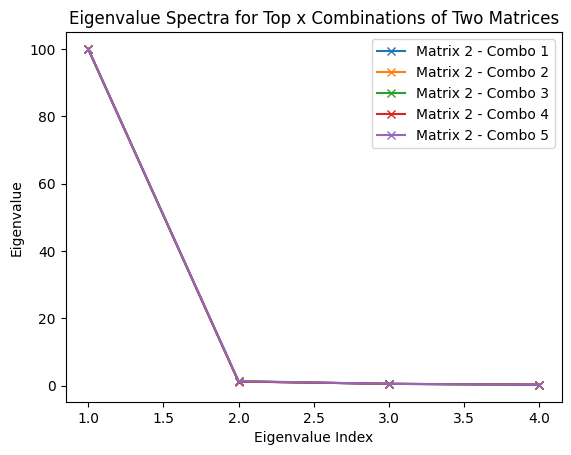

In [76]:

for i, (value, eigenvalues, comb) in enumerate(top_combinations2, start=1):
    indices = np.arange(1, len(eigenvalues) + 1)
    plt.plot(indices, sorted(eigenvalues, reverse=True), label=f'Matrix 2 - Combo {i}', marker='x')

plt.xlabel('Eigenvalue Index')
plt.ylabel('Eigenvalue')
plt.title('Eigenvalue Spectra for Top x Combinations of Two Matrices')
plt.legend()

plt.show()